In [2]:
import pandas as pd
import numpy as np
import re
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


from gensim.models import Word2Vec
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence
from torch.nn.utils import clip_grad_norm_
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [4]:
df = pd.read_parquet("hf://datasets/k1tub/sentiment_dataset/data/train-00000-of-00001.parquet")

df.head()

e:\projects\Проекты по DS\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,text,label,src
0,"Пальто красивое, но пришло с дырой в молнии. П...",0,rureviews
1,"Очень долго шел заказ,ждала к новому году,приш...",0,rureviews
2,"Могу сказать одно, брюки нормальные, НО они бы...",0,rureviews
3,"Доставка быстрая, меньше месяца. Заказывали ра...",0,rureviews
4,Мне не очень понравилось это платье. Размер ...,0,rureviews


In [5]:
df.info()
df["label"].value_counts().sort_index()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290458 entries, 0 to 290457
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    290458 non-null  object
 1   label   290458 non-null  int64 
 2   src     290458 non-null  object
dtypes: int64(1), object(2)
memory usage: 6.6+ MB


label
0    96589
1    96877
2    96992
Name: count, dtype: int64

In [6]:
# По примерам датасета: 0 - neutral/mixed, 1 - positive, 2 - negative.
id2label = {
    0: "neutral",
    1: "positive",
    2: "negative"
}

class_names = [id2label[i] for i in sorted(id2label.keys())]

class_names

['neutral', 'positive', 'negative']

In [7]:
def tokenize(text: str) -> list[str]:
    text = text.lower()
    text = text.replace("ё", "е")

    tokens = re.findall(r"[а-яa-z0-9]+", text)

    return tokens

In [8]:
df = df[['text', 'label']].copy()

df = df.dropna()
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(int)

df["tokens"] = df["text"].apply(tokenize)

df["tokens_len"] = df["tokens"].apply(len)
df["tokens_len"].describe()

count    290458.000000
mean         52.102955
std          56.979820
min           0.000000
25%          11.000000
50%          27.000000
75%          75.000000
max         277.000000
Name: tokens_len, dtype: float64

In [9]:
df = df[df["tokens_len"] > 0].copy()

df.shape

(290398, 4)

In [10]:
X = df["tokens"].values
y = df["label"].values

X_train, X_temp, y_train, y_temp =  train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Train size: {X_train.shape}")
print(f"Validation size: {X_val.shape}")
print(f"Test size: {X_test.shape}")

Train size: (203278,)
Validation size: (43560,)
Test size: (43560,)


In [11]:
w2v_model = Word2Vec(
    sentences=X_train,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10
)



In [22]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

word2idx = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1 
}

for word in w2v_model.wv.index_to_key:
    word2idx[word] = len(word2idx)
    

idx2word = {idx: word for word, idx in word2idx.items() }

vocab_size = len(word2idx)
embedding_dim = w2v_model.vector_size

print(f"Vocab size: {vocab_size}")
print(f"embedding dimension: {embedding_dim}")


Vocab size: 183832
embedding dimension: 100


In [19]:
embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)

embedding_matrix[word2idx[UNK_TOKEN]] = np.random.normal(
    loc=0.0,
    scale=0.1,
    size=(embedding_dim,)
)

for word, idx in word2idx.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32) 

embedding_matrix.shape



torch.Size([183832, 100])

In [14]:
class ReviewsDataset(Dataset):
    def __init__(self, tokenized_text, labels, word2idx, max_len=100):
        self.tokenized_text = tokenized_text
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len

    def encode_tokens(self, tokens):
        ids = [self.word2idx.get(token, self.word2idx[UNK_TOKEN])
               for token in tokens]
        ids = ids[:self.max_len]

        if len(ids) == 0:
            ids = [self.word2idx[UNK_TOKEN]]

        length = len(ids)
        padding_length = self.max_len - length

        ids = ids + [self.word2idx[PAD_TOKEN]] * padding_length

        return ids, length
    
    def __len__(self):
        return len(self.tokenized_text)
    
    def __getitem__(self, idx):
        ids, length = self.encode_tokens(self.tokenized_text[idx])

        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [15]:
MAX_LEN = 100
BATCH_SIZE = 64

train_dataset = ReviewsDataset(tokenized_text=X_train, labels=y_train, word2idx=word2idx, max_len=MAX_LEN)
val_dataset = ReviewsDataset(tokenized_text=X_val, labels=y_val, word2idx=word2idx, max_len=MAX_LEN)
test_dataset = ReviewsDataset(tokenized_text=X_test, labels=y_test, word2idx=word2idx, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size= BATCH_SIZE,
    num_workers=0,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    shuffle=False
)

In [ ]:
class Word2VecVanilaRNN(nn.Module):
    def __init__(
            self, 
            embedding_matrix, 
            hidden_size=96,
            num_layers=1,
            num_classes=3,
            dropout=0.5,
            freeze_embeddings=True):
        super().__init__()

        vocab_size, embedding_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            embeddings=embedding_matrix,
            freeze=freeze_embeddings,
            padding_idx=0
        )
        self.embedding_dropout = nn.Dropout(dropout)

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity="tanh",
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, input_ids, lengths):
        embedded = self.embedding_dropout(self.embedding(input_ids))

        packed_embedded = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, h_n = self.rnn(packed_embedded)

        last_hidden = h_n[-1]

        logits = self.classifier(last_hidden)

        return logits


In [17]:
model = Word2VecVanilaRNN(
    embedding_matrix=embedding_matrix,
    hidden_size=96,
    num_layers=1,
    num_classes=3,
    dropout=0.5,
    freeze_embeddings=True
).to(device)

model

Word2VecVanilaRNN(
  (embedding): Embedding(183832, 100, padding_idx=0)
  (embedding_dropout): Dropout(p=0.5, inplace=False)
  (rnn): RNN(100, 96, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=96, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [18]:
log_loss = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-3
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

Всего параметров: 18,408,611
Обучаемых параметров: 25,411


In [19]:
def train_one_epoche(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader):
        input_ids = batch["input_ids"].to(device)
        lengths = batch["length"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits= model(input_ids, lengths)

        loss = criterion(logits, labels)

        loss.backward()

        clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, accuracy, macro_f1
        

In [20]:
def evalute(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            lengths = batch["length"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids, lengths)

            loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, accuracy, macro_f1, all_preds, all_labels

In [21]:
NUM_EPOCH = 10
PATIENCE = 3
MIN_DELTA = 1e-4
best_model_path = MODEL_PATH / "word2vec_vanilla_rnn.pt"

best_macro_f1 = 0
best_epoch = 0
epochs_without_improvement = 0
history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
}

for epoch in range(NUM_EPOCH):
    train_loss, train_acc, train_f1 = train_one_epoche(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=log_loss,
        device=device
    )

    val_loss, val_acc, val_f1, _, _ = evalute(
        model=model,
        loader= val_loader,
        criterion= log_loss,
        device=device
    )


    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCH} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_acc:.4f} | "
        f"Train macro-F1: {train_f1:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.4f} | "
        f"Val macro-F1: {val_f1:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if val_f1 > best_macro_f1 + MIN_DELTA:
        best_macro_f1 = val_f1
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_without_improvement += 1

    scheduler.step(val_f1)

    if epochs_without_improvement >= PATIENCE:
        print(
            f"Early stopping: validation macro-F1 не улучшается "
            f"{PATIENCE} эпохи подряд. Лучшая эпоха: {best_epoch}."
        )
        break

print(f"Лучшая модель сохранена: {best_model_path}")
print(f"Лучший validation macro-F1: {best_macro_f1:.4f}, эпоха: {best_epoch}")

100%|██████████| 3177/3177 [01:44<00:00, 30.39it/s]


Epoch 1/10 | Train loss: 0.9048 | Train acc: 0.5735 | Train macro-F1: 0.5739 | Val loss: 0.8446 | Val acc: 0.6355 | Val macro-F1: 0.6268 | LR: 0.000300


100%|██████████| 3177/3177 [01:51<00:00, 28.45it/s]


Epoch 2/10 | Train loss: 0.8609 | Train acc: 0.6077 | Train macro-F1: 0.6089 | Val loss: 0.8124 | Val acc: 0.6455 | Val macro-F1: 0.6426 | LR: 0.000300


100%|██████████| 3177/3177 [01:43<00:00, 30.74it/s]


...

Epoch 8/10 | Train loss: 0.8319 | Train acc: 0.6280 | Train macro-F1: 0.6291 | Val loss: 0.7749 | Val acc: 0.6600 | Val macro-F1: 0.6662 | LR: 0.000300


100%|██████████| 3177/3177 [01:53<00:00, 27.98it/s]


Epoch 9/10 | Train loss: 0.8315 | Train acc: 0.6290 | Train macro-F1: 0.6302 | Val loss: 0.7808 | Val acc: 0.6681 | Val macro-F1: 0.6610 | LR: 0.000300


100%|██████████| 3177/3177 [02:00<00:00, 26.39it/s]


Epoch 10/10 | Train loss: 0.8277 | Train acc: 0.6317 | Train macro-F1: 0.6324 | Val loss: 0.7711 | Val acc: 0.6646 | Val macro-F1: 0.6697 | LR: 0.000300
Лучшая модель сохранена: models\word2vec_vanilla_rnn.pt
Лучший validation macro-F1: 0.6697, эпоха: 10


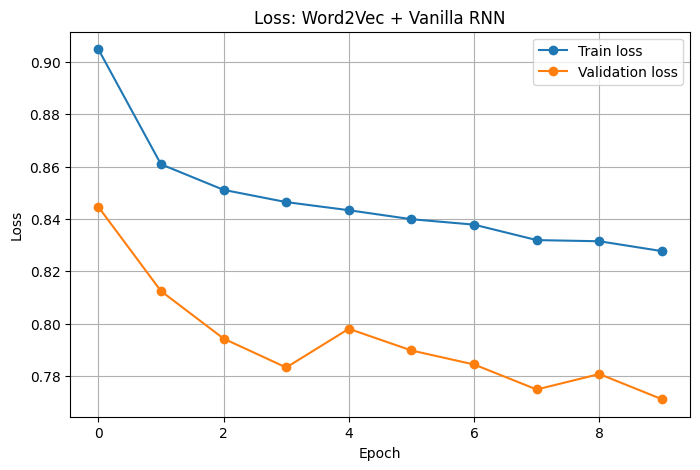

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_loss"], marker="o", label="Train loss")
plt.plot(history["val_loss"], marker="o", label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss: Word2Vec + Vanilla RNN")
plt.legend()
plt.grid(True)
plt.show()

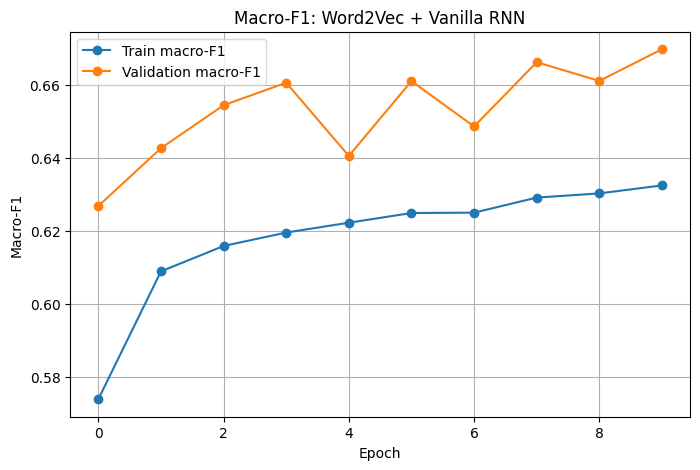

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_f1"], marker="o", label="Train macro-F1")
plt.plot(history["val_f1"], marker="o", label="Validation macro-F1")

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Macro-F1: Word2Vec + Vanilla RNN")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
model.load_state_dict(torch.load("models/word2vec_vanilla_rnn.pt", map_location=device))
model.to(device)

Word2VecVanilaRNN(
  (embedding): Embedding(183832, 100, padding_idx=0)
  (embedding_dropout): Dropout(p=0.5, inplace=False)
  (rnn): RNN(100, 96, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=96, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [25]:
test_loss, test_acc, test_f1, test_preds, test_labels = evalute(
    model,
    test_loader,
    log_loss,
    device
)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))
print("Test macro-F1:", round(test_f1, 4))

Test loss: 0.7679
Test accuracy: 0.6666
Test macro-F1: 0.6718


In [26]:
print(classification_report(
    test_labels,
    test_preds,
    labels=[0, 1, 2],
    target_names=class_names
))

              precision    recall  f1-score   support

    negative       0.55      0.66      0.60     14485
     neutral       0.85      0.68      0.75     14528
    positive       0.67      0.65      0.66     14547

    accuracy                           0.67     43560
   macro avg       0.69      0.67      0.67     43560
weighted avg       0.69      0.67      0.67     43560



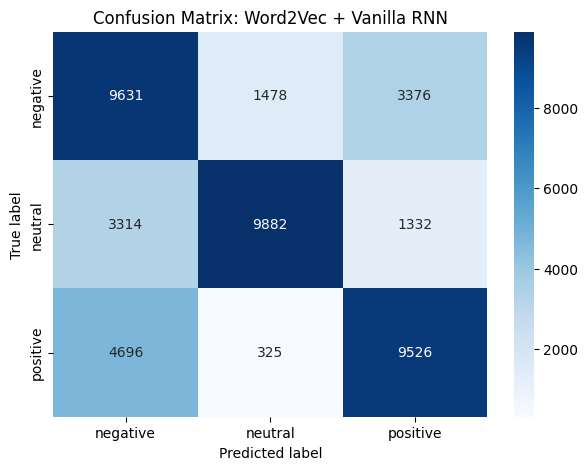

In [28]:
cm = confusion_matrix(
    test_labels,
    test_preds,
    labels=[0, 1, 2]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix: Word2Vec + Vanilla RNN")
plt.show()

In [32]:
def encode_reviews(text, word2idx, max_len=100):
    tokens = tokenize(text)

    ids = [word2idx.get(token, word2idx[UNK_TOKEN])
           for token in tokens]
    
    ids = ids[:max_len]

    if len(ids) == 0:
        ids = [word2idx[UNK_TOKEN]]

    lengths = len(ids)

    padding_lengths = max_len - lengths
    ids = ids + [word2idx[PAD_TOKEN]] * padding_lengths

    input_ids = torch.tensor(ids, dtype=torch.long).unsqueeze(0)
    length = torch.tensor([lengths], dtype=torch.long)

    return input_ids, length

In [33]:
def predict_review_rnn(text, model, word2idx, id2label, max_len=100):
    model.eval()
    input_ids, lengths = encode_reviews(text=text, word2idx=word2idx, max_len=max_len)

    input_ids = input_ids.to(device)
    lengths = lengths.to(device)

    with torch.no_grad():
        logits = model(input_ids, lengths)
        probs = torch.softmax(logits, dim=1)
        pred_id = torch.argmax(probs, dim=1).item()
    
    result = {
        "Текст:": text,
        "Предсказанная метка класса": pred_id,
        "Предсказанный класс":id2label[pred_id],
        "Вероятности": {
            id2label[i]: float(probs[0][i].cpu())
            for i in range(len(id2label))
        }
    }

    return result

In [44]:
predict_review_rnn(
    "Товар пришел быстро, качество отличное, очень доволен покупкой",
    model,
    word2idx,
    id2label,
    max_len=100
)

{'Текст:': 'Товар пришел быстро, качество отличное, очень доволен покупкой',
 'Предсказанная метка класса': 1,
 'Предсказанный класс': 'positive',
 'Вероятности': {'neutral': 0.038656026124954224,
  'positive': 0.9431944489479065,
  'negative': 0.018149590119719505}}

In [45]:
predict_review_rnn(
    "Ужасное качество, больше никогда не буду заказывать",
    model,
    word2idx,
    id2label,
    max_len=100
)

{'Текст:': 'Ужасное качество, больше никогда не буду заказывать',
 'Предсказанная метка класса': 2,
 'Предсказанный класс': 'negative',
 'Вероятности': {'neutral': 0.13678283989429474,
  'positive': 0.023954318836331367,
  'negative': 0.8392627835273743}}

In [46]:
predict_review_rnn(
    "Обычный товар, ничего особенного",
    model,
    word2idx,
    id2label,
    max_len=100
)

{'Текст:': 'Обычный товар, ничего особенного',
 'Предсказанная метка класса': 0,
 'Предсказанный класс': 'neutral',
 'Вероятности': {'neutral': 0.4745086133480072,
  'positive': 0.11432309448719025,
  'negative': 0.41116827726364136}}